In [4]:
# Import packages
import re
from pathlib import Path
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("Imports loaded")

Imports loaded


In [6]:
# Parse directory - UPDATED FOR 3 ENDPOINTS
BASELINE_DIR = Path('/Users/annliang/Documents/breezeblogs_rust/comparison_results/baseline_results_3_endpoints')
SESAME_DIR = Path('/Users/annliang/Documents/breezeblogs_rust/comparison_results/sesame_results_3_endpoints')

print(f"Baseline directory: {BASELINE_DIR.absolute()}")
print(f"Sesame directory: {SESAME_DIR.absolute()}")
print()

# Check directories exist
if not BASELINE_DIR.exists():
    print(f"WARNING: {BASELINE_DIR} does not exist!")
    print(f"Create it or update BASELINE_DIR path")
    
if not SESAME_DIR.exists():
    print(f"WARNING: {SESAME_DIR} does not exist!")
    print(f"Create it or update SESAME_DIR path")

Baseline directory: /Users/annliang/Documents/breezeblogs_rust/comparison_results/baseline_results_3_endpoints
Sesame directory: /Users/annliang/Documents/breezeblogs_rust/comparison_results/sesame_results_3_endpoints



In [7]:
# Parse functions 
def convert_to_ms(value, unit):
    """Convert time value to milliseconds"""
    unit = unit.lower()
    if unit == 'us':
        return value / 1000
    elif unit == 'ms':
        return value
    elif unit == 's':
        return value * 1000
    elif unit == 'm':
        return value * 60000
    return value

def parse_wrk_output(filepath):
    """Parse wrk text output"""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
    except Exception as e:
        print(f"❌ Error reading {filepath}: {e}")
        return {}
    
    metrics = {}
    
    # Check for connection errors
    if 'Connection refused' in content or 'unable to connect' in content:
        print(f"{filepath.name}: Connection refused (server likely crashed)")
        return {'error': 'connection_refused'}
    
    # Extract latency stats
    latency_match = re.search(r'Latency\s+(\d+\.\d+)(\w+)\s+(\d+\.\d+)(\w+)\s+(\d+\.\d+)(\w+)', content)
    if latency_match:
        avg, avg_unit = latency_match.group(1), latency_match.group(2)
        stdev, stdev_unit = latency_match.group(3), latency_match.group(4)
        max_val, max_unit = latency_match.group(5), latency_match.group(6)
        
        metrics['avg_latency_ms'] = convert_to_ms(float(avg), avg_unit)
        metrics['stdev_latency_ms'] = convert_to_ms(float(stdev), stdev_unit)
        metrics['max_latency_ms'] = convert_to_ms(float(max_val), max_unit)
    
    # Extract requests/sec
    req_sec_match = re.search(r'Requests/sec:\s+(\d+\.\d+)', content)
    if req_sec_match:
        metrics['requests_per_sec'] = float(req_sec_match.group(1))
    
    # Extract total requests
    total_match = re.search(r'(\d+)\s+requests in', content)
    if total_match:
        metrics['total_requests'] = int(total_match.group(1))
    
    return metrics

print("Parse functions defined")

Parse functions defined


In [8]:
# Parse the 3 key endpoints only
print("Loading baseline results...")
baseline_files = {
    'get_blog_posts': BASELINE_DIR / 'baseline_get_blog_posts.txt',
    'send_news_mails': BASELINE_DIR / 'baseline_send_news_mails.txt',
    'get_interests': BASELINE_DIR / 'baseline_get_interests.txt',
    'set_interests': BASELINE_DIR / 'baseline_set_interests.txt',
}

print("Loading Sesame results...")
sesame_files = {
    'get_blog_posts': SESAME_DIR / 'sesame_get_blog_posts.txt',
    'send_news_mails': SESAME_DIR / 'sesame_send_news_mails.txt',
    'get_interests': SESAME_DIR / 'sesame_get_interests.txt',
    'set_interests': SESAME_DIR / 'sesame_set_interests.txt',
}

# Parse all files
baseline_results = {}
sesame_results = {}

print("\nParsing baseline files...")
for endpoint, filepath in baseline_files.items():
    if filepath.exists():
        metrics = parse_wrk_output(filepath)
        if 'avg_latency_ms' in metrics:
            baseline_results[endpoint] = metrics
            print(f"  ✓ {endpoint}: {metrics['avg_latency_ms']:.2f} ms")
        else:
            print(f"  ✗ {endpoint}: Failed to parse")
    else:
        print(f"  ✗ {endpoint}: File not found")

print("\nParsing Sesame files...")
for endpoint, filepath in sesame_files.items():
    if filepath.exists():
        metrics = parse_wrk_output(filepath)
        if 'avg_latency_ms' in metrics:
            sesame_results[endpoint] = metrics
            print(f"  ✓ {endpoint}: {metrics['avg_latency_ms']:.2f} ms")
        else:
            print(f"  ✗ {endpoint}: Failed to parse")
    else:
        print(f"  ✗ {endpoint}: File not found")

print(f"\n✓ Parsed {len(baseline_results)} baseline endpoints")
print(f"✓ Parsed {len(sesame_results)} Sesame endpoints")

Loading baseline results...
Loading Sesame results...

Parsing baseline files...
  ✓ get_blog_posts: 5.13 ms
  ✓ send_news_mails: 2.26 ms
  ✓ get_interests: 7.10 ms
  ✓ set_interests: 6.36 ms

Parsing Sesame files...
  ✓ get_blog_posts: 2.87 ms
  ✓ send_news_mails: 2.19 ms
  ✓ get_interests: 2.64 ms
  ✓ set_interests: 5.77 ms

✓ Parsed 4 baseline endpoints
✓ Parsed 4 Sesame endpoints


OUR DATA - 3 ENDPOINT CATEGORIES (Matching Paper)

Individual Endpoint Breakdown:
  blog-posts:
    Baseline: 5.1 ms
    Sesame:   2.9 ms

  send-news-mails:
    Baseline: 2.3 ms
    Sesame:   2.2 ms

  interests (avg of GET + SET):
    GET baseline: 7.1 ms, SET baseline: 6.4 ms
    GET sesame:   2.6 ms, SET sesame:   5.8 ms
    Average baseline: 6.7 ms
    Average sesame:   4.2 ms

AGGREGATED TOTALS (SUM of 3 endpoint categories):
  Baseline Total:    14.1 ms
  Sesame Total:      9.3 ms
  Overhead:          -34.4%


✓ Comparison plot saved: framework_comparison_aggregated.png


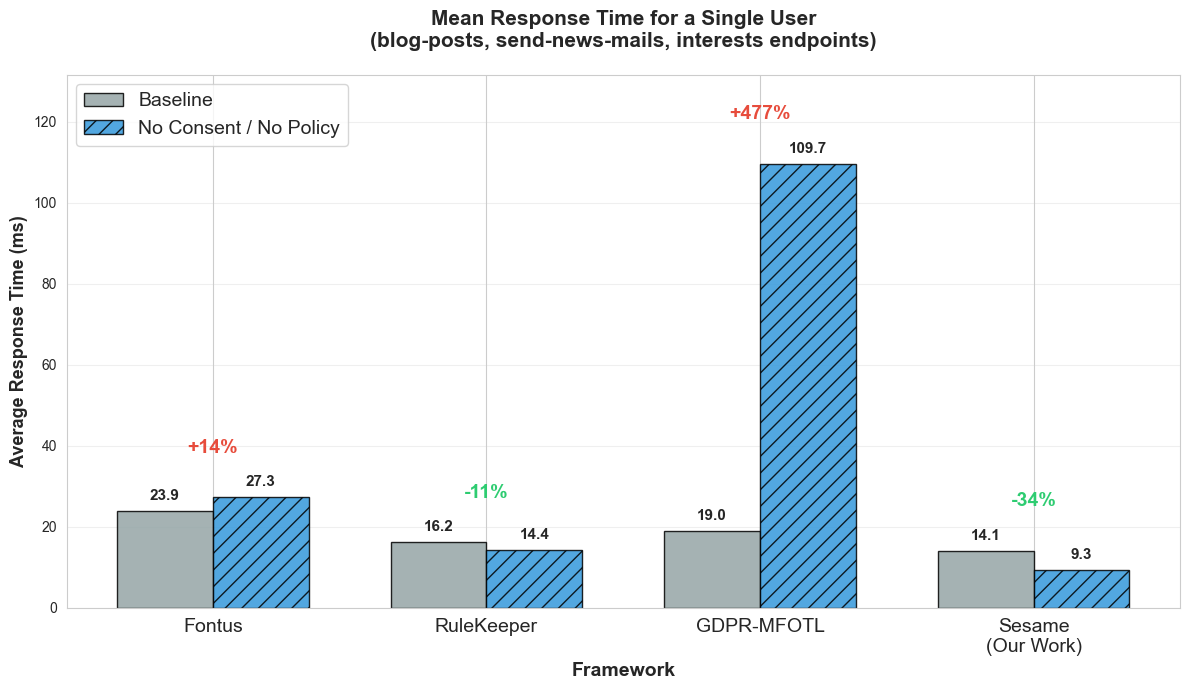


FRAMEWORK COMPARISON - AGGREGATED RESPONSE TIME
Framework            Baseline (ms)   No-Consent (ms)      Overhead       
--------------------------------------------------------------------------------
Fontus               23.9            27.3                          +14.2%
RuleKeeper           16.2            14.4                          -11.1%
GDPR-MFOTL           19.0            109.7                        +477.4%
Sesame
(Our Work)    14.1            9.3                           -34.4%

Note: Response time is the SUM of three endpoint categories:
  - blog-posts (get_blog_posts)
  - send-news-mails (send_news_mails)
  - interests (AVERAGE of get_interests + set_interests)

Methodology: Matches paper's single-user benchmark over ~13 minutes total


In [9]:
# Create GDPR Paper Style Visual - Aggregated Comparison
# This matches the paper's methodology: sum of 3 endpoint categories

print("="*80)
print("OUR DATA - 3 ENDPOINT CATEGORIES (Matching Paper)")
print("="*80)
print()

# Calculate individual endpoint values
blog_posts_baseline = baseline_results.get('get_blog_posts', {}).get('avg_latency_ms', 0)
blog_posts_sesame = sesame_results.get('get_blog_posts', {}).get('avg_latency_ms', 0)

send_mails_baseline = baseline_results.get('send_news_mails', {}).get('avg_latency_ms', 0)
send_mails_sesame = sesame_results.get('send_news_mails', {}).get('avg_latency_ms', 0)

# Interests: AVERAGE of get_interests and set_interests
get_int_baseline = baseline_results.get('get_interests', {}).get('avg_latency_ms', 0)
set_int_baseline = baseline_results.get('set_interests', {}).get('avg_latency_ms', 0)
interests_baseline = (get_int_baseline + set_int_baseline) / 2

get_int_sesame = sesame_results.get('get_interests', {}).get('avg_latency_ms', 0)
set_int_sesame = sesame_results.get('set_interests', {}).get('avg_latency_ms', 0)
interests_sesame = (get_int_sesame + set_int_sesame) / 2

print("Individual Endpoint Breakdown:")
print(f"  blog-posts:")
print(f"    Baseline: {blog_posts_baseline:.1f} ms")
print(f"    Sesame:   {blog_posts_sesame:.1f} ms")
print()
print(f"  send-news-mails:")
print(f"    Baseline: {send_mails_baseline:.1f} ms")
print(f"    Sesame:   {send_mails_sesame:.1f} ms")
print()
print(f"  interests (avg of GET + SET):")
print(f"    GET baseline: {get_int_baseline:.1f} ms, SET baseline: {set_int_baseline:.1f} ms")
print(f"    GET sesame:   {get_int_sesame:.1f} ms, SET sesame:   {set_int_sesame:.1f} ms")
print(f"    Average baseline: {interests_baseline:.1f} ms")
print(f"    Average sesame:   {interests_sesame:.1f} ms")
print()

# Calculate totals (SUM of the 3 categories)
our_baseline_total = blog_posts_baseline + send_mails_baseline + interests_baseline
our_sesame_total = blog_posts_sesame + send_mails_sesame + interests_sesame
our_overhead = ((our_sesame_total - our_baseline_total) / our_baseline_total * 100) if our_baseline_total > 0 else 0

print("="*80)
print("AGGREGATED TOTALS (SUM of 3 endpoint categories):")
print("="*80)
print(f"  Baseline Total:    {our_baseline_total:.1f} ms")
print(f"  Sesame Total:      {our_sesame_total:.1f} ms")
print(f"  Overhead:          {our_overhead:+.1f}%")
print()

# Data from GDPR paper Figure 4
fontus = {
    'baseline': 23.9, 
    'no_consent': 27.3, 
}

rulekeeper = {
    'baseline': 16.2,
    'no_consent': 14.4, 
}

gdpr_mfotl = {
    'baseline': 19.0,
    'no_consent': 109.7,
}

# Create the comparison plot
fig, ax = plt.subplots(figsize=(12, 7))

# Data
frameworks = ['Fontus', 'RuleKeeper', 'GDPR-MFOTL', 'Sesame\n(Our Work)']
baseline_vals = [
    fontus['baseline'],
    rulekeeper['baseline'],
    gdpr_mfotl['baseline'],
    our_baseline_total
]
no_consent_vals = [
    fontus['no_consent'],
    rulekeeper['no_consent'],
    gdpr_mfotl['no_consent'],
    our_sesame_total
]

x = np.arange(len(frameworks))
width = 0.35

# Bars
bars1 = ax.bar(x - width/2, baseline_vals, width, 
               label='Baseline', alpha=0.85, color='#95a5a6',
               edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, no_consent_vals, width,
               label='No Consent / No Policy', alpha=0.85, color='#3498db',
               edgecolor='black', linewidth=1, hatch='//')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Calculate and display overhead percentages
for i, (base, nocon) in enumerate(zip(baseline_vals, no_consent_vals)):
    if base > 0:
        overhead = ((nocon - base) / base * 100)
        # Add overhead % above the bars
        max_height = max(base, nocon)
        ax.text(i, max_height + 10, f'{overhead:+.0f}%',
                ha='center', va='bottom', fontsize=14, 
                color='#e74c3c' if overhead > 0 else '#2ecc71',
                fontweight='bold')

# Formatting
ax.set_xlabel('Framework', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Response Time (ms)', 
              fontsize=13, fontweight='bold')
ax.set_title('Mean Response Time for a Single User\n' +
             '(blog-posts, send-news-mails, interests endpoints)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(frameworks, fontsize=14)
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(baseline_vals + no_consent_vals) * 1.2)

plt.tight_layout()
plt.savefig('framework_comparison_aggregated.png', dpi=300, bbox_inches='tight')
print("\n✓ Comparison plot saved: framework_comparison_aggregated.png")
plt.show()

# Print comparison table
print("\n" + "="*80)
print("FRAMEWORK COMPARISON - AGGREGATED RESPONSE TIME")
print("="*80)
print(f"{'Framework':<20} {'Baseline (ms)':<15} {'No-Consent (ms)':<20} {'Overhead':<15}")
print("-"*80)
for i, fw in enumerate(frameworks):
    base = baseline_vals[i]
    nocon = no_consent_vals[i]
    overhead = ((nocon - base) / base * 100) if base > 0 else 0
    print(f"{fw:<20} {base:<15.1f} {nocon:<20.1f} {overhead:>+14.1f}%")
print("="*80)

print("\nNote: Response time is the SUM of three endpoint categories:")
print("  - blog-posts (get_blog_posts)")
print("  - send-news-mails (send_news_mails)")
print("  - interests (AVERAGE of get_interests + set_interests)")
print("\nMethodology: Matches paper's single-user benchmark over ~13 minutes total")